In [8]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np

data = fetch_california_housing(as_frame=True)
df = data.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [9]:
x = df['MedInc'].values
y = df['MedHouseVal'].values

print(x.shape, y.shape)

(20640,) (20640,)


In [10]:
def predict(x, w, b):
    return w * x + b

In [11]:
w = 0
b = 0
predictions = predict(x, w, b)
print(predictions[:5])

[0. 0. 0. 0. 0.]


In [12]:
def compute_cost(x, y, w, b):
    m = len(y)
    
    predictions = predict(x, w, b)      
    errors = predictions - y             
    squared_errors = errors ** 2        
    total = np.sum(squared_errors)     
    cost = (1 / (2 * m)) * total         
    
    return cost

In [13]:
def gradient_descent(x, y, w, b, alpha, iterations):
    m = len(y)
    
    for i in range(iterations):
        predictions = predict(x, w, b)
        errors = predictions - y
        
        dj_dw = (1/m) * np.sum(errors * x)
        dj_db = (1/m) * np.sum(errors)
        
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
    
    return w, b

In [14]:
w_init = 0
b_init = 0
alpha = 0.01
iterations = 1000

w_final, b_final = gradient_descent(x, y, w_init, b_init, alpha, iterations)
print(w_final, b_final)

0.42929964682709043 0.3968328509928906


In [15]:
avg_income = x.mean()
avg_price = y.mean()

predicted = predict(avg_income, w_final, b_final)
print("Average income:", avg_income)
print("Average actual price:", avg_price)
print("Model's prediction at average income:", predicted)

Average income: 3.8706710029069766
Average actual price: 2.0685581690891475
Model's prediction at average income: 2.0585105455247157


Matplotlib is building the font cache; this may take a moment.


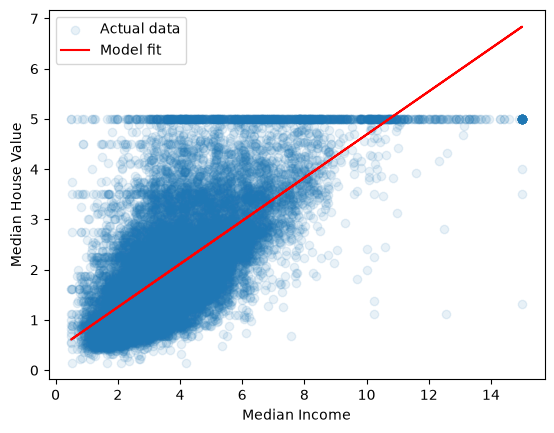

In [16]:
import matplotlib.pyplot as plt

plt.scatter(x, y, alpha=0.1, label='Actual data')
plt.plot(x, predict(x, w_final, b_final), color='red', label='Model fit')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.legend()
plt.show()